In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt

In [2]:
def group_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            ws = int(match.group(4))
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws
            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['ws', 'alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum'}) \
        .reset_index()
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['clicks']
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['true_clicks']
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['impressions']
    # Calcolo CTR e True CTR
    grouped_results['ctr'] = grouped_results['clicks'] / grouped_results['impressions']
    grouped_results['true_ctr'] = grouped_results['true_clicks'] / grouped_results['impressions']
    return grouped_results

In [3]:
dir_path = '../results/FP_DM_Oracle_sigmoids_sw_cucb_alpha_0_ws_70/'

In [4]:
grouped_results = group_data(dir_path)

In [5]:
grouped_results.to_csv(f'{dir_path}grouped_results.csv', index=False)

In [20]:
def plot_mul_gr_sw(gr_res_models, iteration=1, quantity='clicks', optimal_quantity=None, alpha_to_exclude=[]):
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    plt.figure(figsize=(10, 6))
    for alpha in unique_alphas:
        if alpha_to_exclude and alpha in alpha_to_exclude:
            continue
        for model, gr_res in gr_res_models.items():
            model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)]
            if 'ws' in model_data.columns:
                win_sizes = model_data['ws'].unique()
                for ws in win_sizes:
                    curr_data = model_data[model_data['ws'] == ws]
                    plt.plot(curr_data['Iteration'].to_numpy(), curr_data[quantity].to_numpy(), label=f'{model} α={alpha} ws={ws}')
                    if f'{quantity}_ci' in model_data.columns:
                        plt.fill_between(curr_data['Iteration'].to_numpy(), 
                                        curr_data[quantity].to_numpy() -  curr_data[f'{quantity}_ci'].to_numpy(), 
                                        curr_data[quantity].to_numpy() +  curr_data[f'{quantity}_ci'].to_numpy(), 
                                        alpha=0.2)
            else:
                plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
                if f'{quantity}_ci' in model_data.columns:
                    plt.fill_between(model_data['Iteration'].to_numpy(), 
                                    model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                    model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                    alpha=0.2)
    if optimal_quantity:
        plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'optimal {quantity}')
    plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1}')
    plt.xlabel('Iteration')
    plt.ylabel(quantity)
    plt.legend()
    plt.tight_layout()
    plt.show()

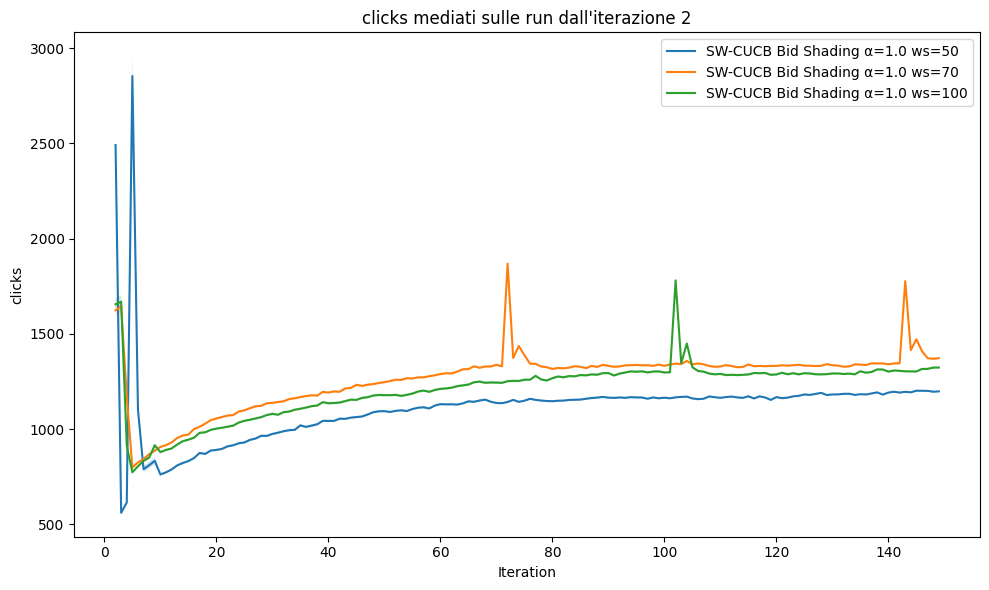

In [19]:
models = {
    'SW-CUCB Bid Shading': grouped_results
}
plot_mul_gr_sw(models, iteration=1, quantity='clicks')

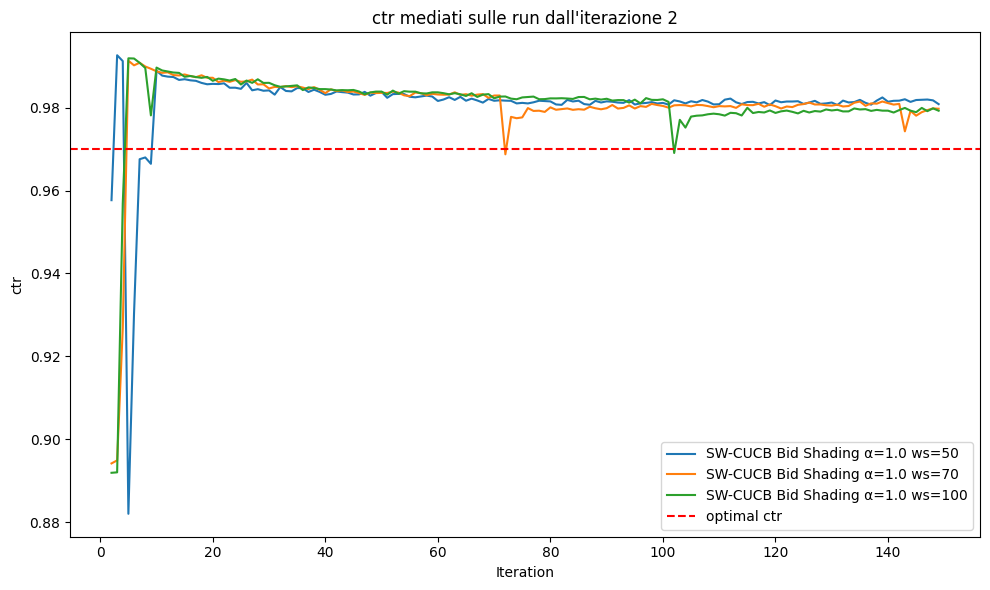

In [22]:
plot_mul_gr_sw(models, iteration=1, quantity='ctr', optimal_quantity=0.97)

In [21]:
data_tp = grouped_results[(grouped_results['alpha'] == 1)&(grouped_results['Iteration'] > 1)]

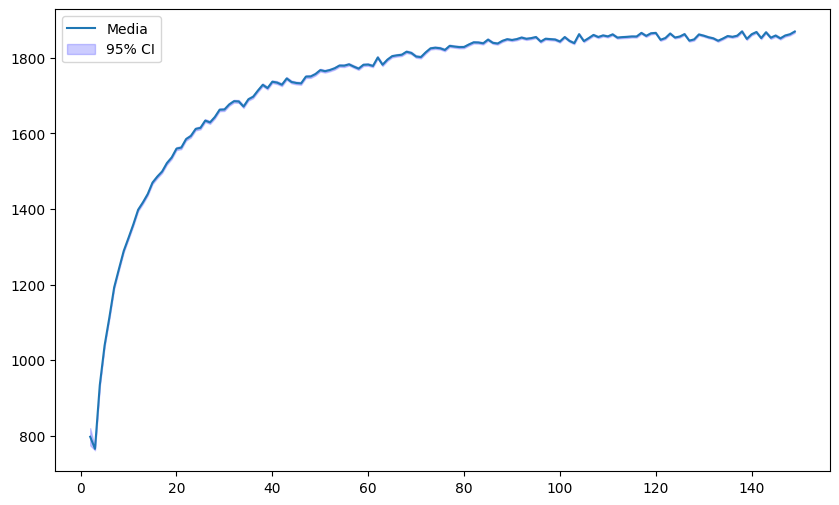

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(data_tp['Iteration'].to_numpy(), data_tp['clicks'].to_numpy(), label='Media')
plt.fill_between(data_tp['Iteration'].to_numpy(), 
                 data_tp['clicks'].to_numpy() -  data_tp['clicks_ci'].to_numpy(), 
                 data_tp['clicks'].to_numpy() +  data_tp['clicks_ci'].to_numpy(), 
                 color='b', alpha=0.2, label='95% CI')
plt.legend()
plt.show()